# Demo Notebook

This notebook demonstrates how to run the Spatial Information Reconstruction Framework (SIRF) using the default configuration.

It loads a dataset from `data/<dataset_name>/bus.csv` and `data/<dataset_name>/branch.csv`, runs the reconstruction, and inspects the outputs in `results/<experiment_name>/`.

In [7]:
# 1. Imports
import yaml
import pandas as pd
import os

import sirf

In [8]:
# 2. Load config
with open('configs/default.yaml', 'r') as f:
    config = yaml.safe_load(f)

config['inference']['min_corr'] = 0.995     # default: 0.9
config

{'data': {'dataset': 'demo',
  'data_dir': 'data',
  'node_file': 'bus.csv',
  'link_file': 'branch.csv'},
 'searching': {'enable': True, 'country': 'Korea', 'component_n': 1},
 'inference': {'enable': True,
  'retention_rate': 1.0,
  'iter_num': 33,
  'regression_poly_degree': 1,
  'include_bias': False,
  'iter_n': 10000,
  'min_corr': 0.995,
  'num_seed': 42},
 'logging': {'level': 'INFO'}}

In [9]:
# 3. Run framework
sirf.run(config)   # will read bus.csv / branch.csv and save outputs to results/demo/

  Geocoding 10 unique Facility_name(s) (skipping 0 duplicate rows) ...


  Geocoding: 100%|██████████| 10/10  100%  [00:09<00:00,  1.10name/s]
2026-02-26 03:48:26,140 | INFO | [infer] starting pipeline (config-driven, non-ensemble).


  Done — 9/10 resolved, 1 not found.
Lower than the seed data rate : 90.0 %
Seed data rate (Exceeded): 90.0 %
1st infer correlation: 0.9670719745958686


  3%|▎         | 324/10000 [00:00<00:00, 20725.25it/s]
2026-02-26 03:48:26,216 | INFO | [infer] filtering+reinfer iteration 1, current correlation 0.972043054987832


Number of Iteration: 325
Node to add: 6


...

Number of Iteration: 218
Node to add: 5


  2%|▏         | 200/10000 [00:00<00:01, 5622.88it/s]


Number of Iteration: 201


2026-02-26 03:48:26,464 | INFO | [infer] Position inference completed.
2026-02-26 03:48:26,465 | INFO | Saved: /Users/jaiyong/Library/CloudStorage/OneDrive-개인/4. KENTECH/1. 연구 및 과제/1. 진행/2022_전력망노드위치추정/2. After 2024/Git_upload/SIRF/results/demo/bus.csv
2026-02-26 03:48:26,465 | INFO | Saved: /Users/jaiyong/Library/CloudStorage/OneDrive-개인/4. KENTECH/1. 연구 및 과제/1. 진행/2022_전력망노드위치추정/2. After 2024/Git_upload/SIRF/results/demo/branch.csv
2026-02-26 03:48:26,465 | INFO | Logs:  /Users/jaiyong/Library/CloudStorage/OneDrive-개인/4. KENTECH/1. 연구 및 과제/1. 진행/2022_전력망노드위치추정/2. After 2024/Git_upload/SIRF/results/demo/logs.txt


(   Node Facility_name  Latitude_truth  Longitude_truth   Latitude   Longitude
 0     1         Seoul       37.566679       126.978291  37.360496  126.994937
 1     2         Busan       35.179953       129.075236  35.179953  129.075236
 2     3         Daegu       35.871300       128.601800  35.871300  128.601800
 3     4       Incheon       37.456000       126.705200  37.456000  126.705200
 4     5       Gwangju       35.159465       126.851503  35.141914  126.844192
 5     6       Daejeon       36.349701       127.384902  36.222222  127.462323
 6     7         Ulsan       35.539170       129.311914  35.650459  129.472926
 7     8        Sejong       36.480000       127.289000  36.461418  127.523066
 8     9         Wonju       37.342100       127.919760  37.342100  127.919760
 9    10       Suwo(n)             NaN              NaN  37.126199  126.824952,
     Node1  Node2  Length_km  Resistance  Reactance  Latitude_1  Longitude_1  \
 0       1      4       28.0      0.0084     0.022

In [10]:
# 4. Inspect results
iter_num = config["inference"]["iter_num"]
suffix = f"{int(config['inference']['retention_rate']*100)}p_{int(iter_num):04d}"

bus_path = "results/" + config['data']['dataset'] + "/bus.csv"
branch_path = "results/" + config['data']['dataset'] + "/branch.csv"

if os.path.exists(bus_path) and os.path.exists(branch_path):
    print("Loading final outputs (bus.csv, branch.csv)...")
    bus = pd.read_csv(bus_path)
    branch = pd.read_csv(branch_path)
else:
    print("Final outputs not found, loading aligned data...")
    bus = pd.read_csv(f"results/{config['data']['dataset']}/Aligned_data/Bus_aligned/Bus_aligned_{suffix}.csv")
    branch = pd.read_csv(f"results/{config['data']['dataset']}/Aligned_data/Branch_aligned/Branch_aligned_{suffix}.csv")

bus.head(), branch.head()

Final outputs not found, loading aligned data...


(   Node Facility_name  Latitude_truth  Longitude_truth   Latitude   Longitude
 0     1         Seoul       37.566679       126.978291  37.360496  126.994937
 1     2         Busan       35.179953       129.075236  35.179953  129.075236
 2     3         Daegu       35.871300       128.601800  35.871300  128.601800
 3     4       Incheon       37.456000       126.705200  37.456000  126.705200
 4     5       Gwangju       35.159465       126.851503  35.141914  126.844192,
    Node1  Node2  Length_km  Resistance  Reactance  Latitude_1  Longitude_1  \
 0      1      4       28.0      0.0084     0.0224   37.360496   126.994937   
 1      1     10       35.0      0.0105     0.0280   37.360496   126.994937   
 2      1      9       87.0      0.0261     0.0696   37.360496   126.994937   
 3     10      6      125.0      0.0375     0.1000   37.126199   126.824952   
 4      6      5      140.0      0.0420     0.1120   36.222222   127.462323   
 
    Latitude_2  Longitude_2    Distance  Predicte

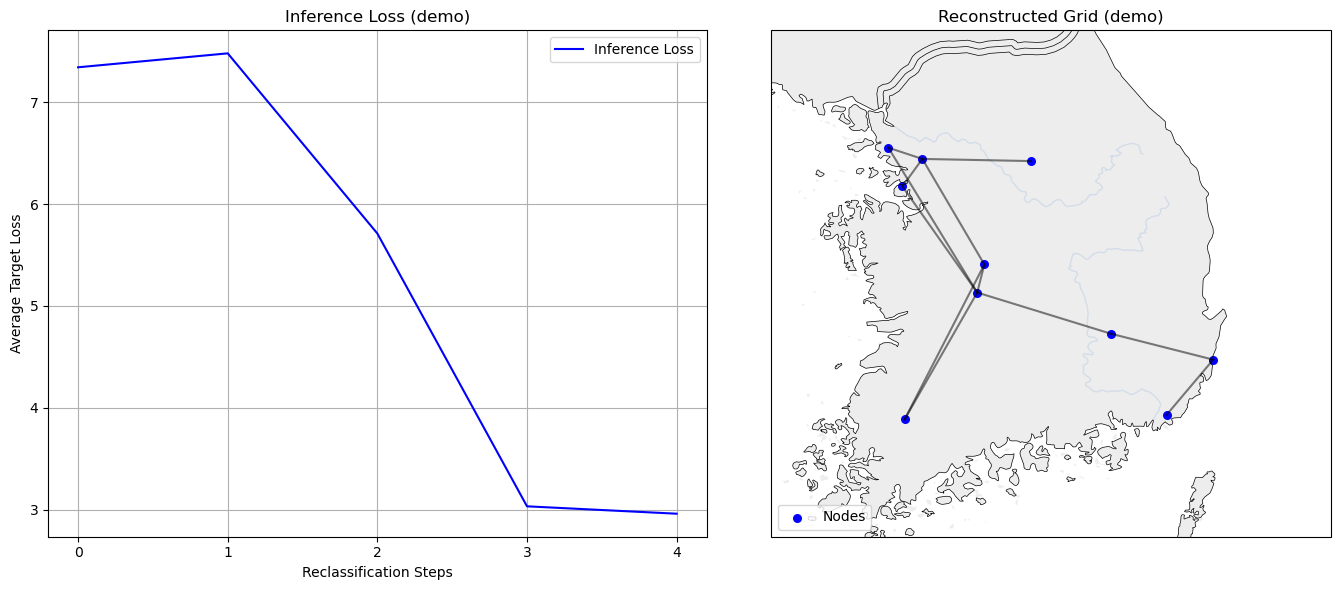

In [11]:
# 5. Simple visualization of reconstructed nodes
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 5-1. Load inference loss
inference_loss_path = os.path.join(
    "results",
    config['data']['dataset'],
    "Inferred_data",
    "Inference_loss",
    f"Inference_loss_{suffix}.csv"
)

inference_loss = pd.read_csv(inference_loss_path, header=None)
loss_values = inference_loss.iloc[0].tolist()

# 5-2. Prepare bus/branch data
if "Latitude" not in bus.columns and "Longitude" not in bus.columns:
    bus = bus.rename(
        columns={
            "Longitude_truth": "Longitude",
            "Latitude_truth": "Latitude"
        }
    )

# 5-3. Create subplots
fig = plt.figure(figsize=(14, 6))

# ---------------------------
# Left: Inference Loss
# ---------------------------
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(loss_values, label='Inference Loss', color='blue')
ax1.set_title(f"Inference Loss ({config['data']['dataset']})")
ax1.set_xlabel('Reclassification Steps')
ax1.set_ylabel('Average Target Loss')
ax1.legend()
ax1.grid(True)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))

# ---------------------------
# Right: Reconstructed Grid with world map
# ---------------------------
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_title(f"Reconstructed Grid ({config['data']['dataset']})")

# Add map background
ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.LAKES, alpha=0.3)
ax2.add_feature(cfeature.RIVERS, alpha=0.3)

# Node display
ax2.scatter(bus['Longitude'], bus['Latitude'], s=30, c='blue',
            label='Nodes', transform=ccrs.PlateCarree())

# Branch connections
for _, row in branch.iterrows():
    n1 = bus[bus['Node'] == row['Node1']].iloc[0]
    n2 = bus[bus['Node'] == row['Node2']].iloc[0]
    ax2.plot([n1['Longitude'], n2['Longitude']],
             [n1['Latitude'], n2['Latitude']],
             'k-', alpha=0.5, transform=ccrs.PlateCarree())

ax2.legend(loc='lower left')

# Automatically adjust axes to fit data range
lon_min, lon_max = bus['Longitude'].min(), bus['Longitude'].max()
lat_min, lat_max = bus['Latitude'].min(), bus['Latitude'].max()
ax2.set_extent([lon_min - 1, lon_max + 1, lat_min - 1, lat_max + 1], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()